<div style="background-color: steelblue; padding: 10px; border-radius: 5px;">
    <p style="margin: 10;"></p>
    <h1 style="text-align: center; margin: 0; font-weight: bold; color: white;">SWOT OMIP : Seasonality ratio</h1>
    <p style="margin: 10;"></p>
</div>


## 📦**Imports** 

In [1]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
from widetrax import DataPreprocessing as dp
from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
from shapely.geometry import shape, box

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
#from widetrax import Spectra as sp
import plot_psd1Xglobal1 as pp2X

CPU times: user 2.34 s, sys: 508 ms, total: 2.84 s
Wall time: 3.54 s


## **Load boxes position**

In [2]:
# CONFIG

# NOT MODIFY

roi = {
        "lon_min": -180,
        "lon_max": 180,
        "lat_min": -90,
        "lat_max": 90
}
pos_reg=[-180, -90, 180, 90]

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

roi_poly = box(roi["lon_min"], roi["lat_min"],
               roi["lon_max"], roi["lat_max"])

selected = []

for feature in data["features"]:
    poly = shape(feature["geometry"])
    if poly.intersects(roi_poly):
        selected.append(poly)

north_boxes = []
south_boxes = []

for i, feature in enumerate(data["features"]):

    coords = feature["geometry"]["coordinates"][0]

    lats = [c[1] for c in coords]

    lat_center = sum(lats) / len(lats)

    if lat_center >= 0:
        north_boxes.append(i)
    else:
        south_boxes.append(i)

print("North boxes:", len(north_boxes))
print("South boxes:", len(south_boxes))
print(north_boxes)

North boxes: 93
South boxes: 189
[189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281]


## **Plotting**
**Estimate the Winter/Summer ratio.**
* In the Southern Hemisphere this corresponds to JAS/JFM, while in the Northern Hemisphere it is JFM/JAS.
  

In [23]:

import plot_ration_psdglobal as ppR


#MODEL LOAD
models=["GLO12","GLO36","NOC12","NOC025","SWOT"]



box=0
#psdsW=np.zeros((21,len(selected),5))
#psdsS=np.zeros((21,len(selected),5))

R0=[]
R1=[]
R2=[]
R3=[]
R4=[]
F=[]
for i, poly in enumerate(selected):
    psdsW=np.zeros((len(selected),5))
    psdsS=np.zeros((len(selected),5))
    if (i!=14) and (i!=15):
        season="JFM"
        spectrumJFM=[]
        freqJFM=[]
        # Plot spectrum JFM
        for imod in ["GLO12V4","GLO36V1","NOC12","NOC025","SWOT"]:
            filename = "GLOBALv2/" + imod +  "/Global_box_" + str(box) + "_" + season + "_" + imod + ".json"
            with open(filename, "r") as f:
                data = json.load(f)
            spectrumJFM.append(data["Spectra"])
            freqJFM.append(data["Frequency"])

        season="JAS"
        spectrumJAS=[]
        freqJAS=[]
        # Plot spectrum JAS
        for imod in ["GLO12V4","GLO36V1","NOC12","NOC025","SWOT"]:
            filename = "GLOBALv2/" + imod +  "/Global_box_" + str(box) + "_" + season + "_" + imod + ".json"
            with open(filename, "r") as f:
                data = json.load(f)
            spectrumJAS.append(data["Spectra"])
            freqJAS.append(data["Frequency"])


        wavelength=1/np.array(freqJFM)
        imodel=4
        poswl=np.where((wavelength[imodel]>50) & (wavelength[imodel]<500))

        for imodel in range(5): 
            poswl=np.where((wavelength[imodel]>50) & (wavelength[imodel]<500))
            spectrumJFMM=np.array(spectrumJFM[imodel])
            spectrumJASM=np.array(spectrumJAS[imodel])
            freqJASM = np.array(freqJAS[imodel])   # now it's a 2D array
            dk = np.gradient(freqJASM[poswl[0]])
            if box in north_boxes:
                #psdsW=(np.cumsum(spectrumJFMM[poswl[0]] * dk))
                #psdsS=(np.cumsum(spectrumJASM[poswl[0]] * dk))
                psdsW=((spectrumJFMM[poswl[0]] ))
                psdsS=((spectrumJASM[poswl[0]] ))
            elif box in south_boxes:
                psdsW=(np.cumsum(spectrumJASM[poswl[0]] * dk))
                psdsS=(np.cumsum(spectrumJFMM[poswl[0]] * dk))
                psdsW=((spectrumJASM[poswl[0]]))
                psdsS=((spectrumJFMM[poswl[0]] ))
            #psds1[box,imodel] = np.squeeze(np.cumsum(ratio[poswl[0]] * freqJASM[poswl[0]])/np.sum( 1/freqJASM[poswl[0]]))
            if imodel == 0:
                Z0=psdsW/psdsS
            elif imodel == 1:
                Z1=psdsW/psdsS
            elif imodel == 2:
                Z2=psdsW/psdsS
            elif imodel == 3:
                Z3=psdsW/psdsS
            elif imodel == 4:
                Z4=psdsW/psdsS

          

        R0.append(Z0)
        R1.append(Z1)
        R2.append(Z2)
        R3.append(Z3)
        R4.append(Z4)
        F.append(freqJASM[poswl[0]])
        box=box+1
    else:
        box=box+1


    


/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_27711/2507263543.py:46: RuntimeWarning: divide by zero encountered in divide
  wavelength=1/np.array(freqJFM)


## Plot for SWOT dataset of the ratio between winter/summer spectrum. Each subplot is a show an interval of boxes. Colorbar represents the number of the boxes. See map below for the number boxes

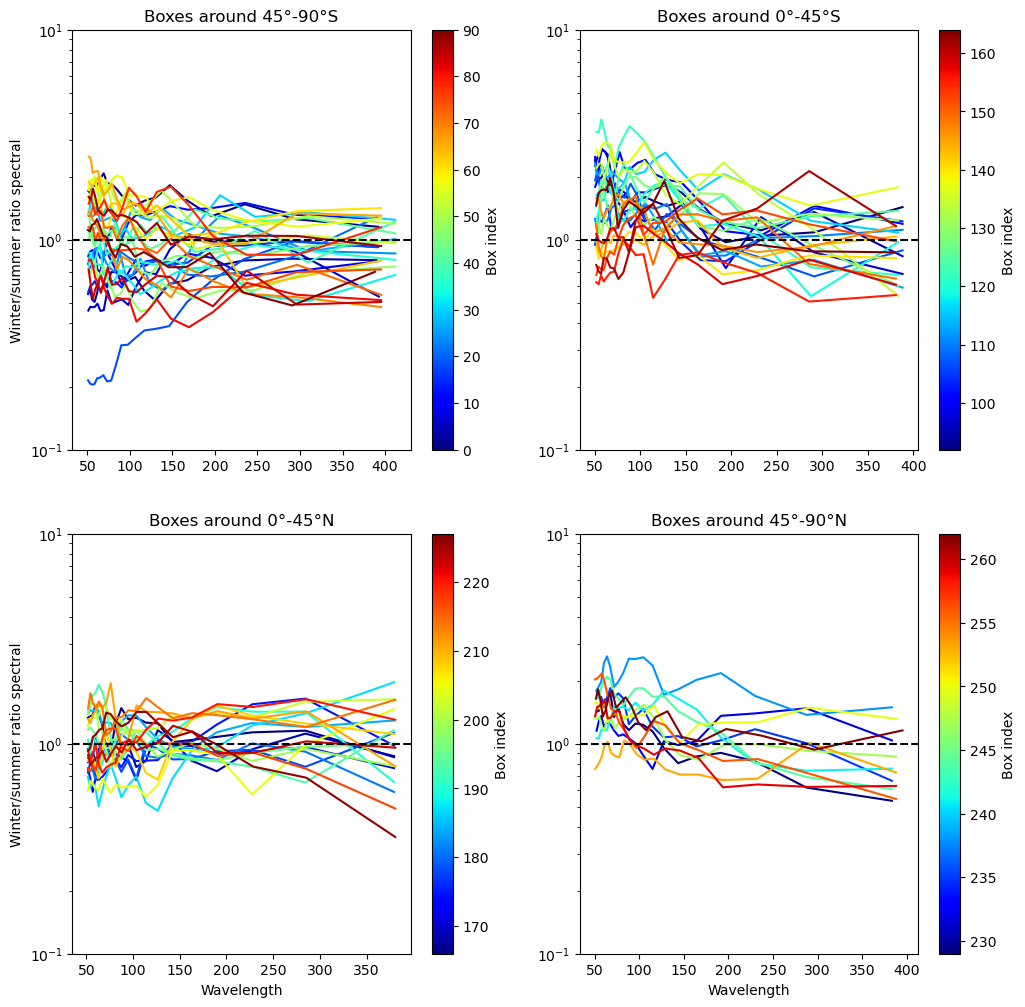

In [58]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

R = R4#[::20]
F2 = F#[::20]

cmap = cm.jet


fig, ax = plt.subplots(2, 2,figsize=(12, 12))   
valmin=0
valmax=91
norm = mcolors.Normalize(vmin=valmin, vmax=valmax-1)
for i in range(valmin,valmax,3): #len(R)):
    ax[0,0].plot(1/F2[i], R[i], color=cmap(norm(i)))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax[0,0], label="Box index")  #
#ax.set_xscale("log")
ax[0,0].axhline(y=1, color='k', linestyle='--')
ax[0,0].set_yscale("log")
ax[0,0].set_ylim(1e-1, 1e1)
ax[0,0].set_title("Boxes around 45°-90°S")
ax[0,0].set_ylabel("Winter/summer ratio spectral")

#_______
valmin=92
valmax=165
norm = mcolors.Normalize(vmin=valmin, vmax=valmax-1)
for i in range(valmin,valmax,3): #len(R)):
    ax[0,1].plot(1/F2[i], R[i], color=cmap(norm(i)))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax[0,1], label="Box index")  #
ax[0,1].axhline(y=1, color='k', linestyle='--')

#ax.set_xscale("log")
ax[0,1].set_yscale("log")
ax[0,1].set_ylim(1e-1, 1e1)
ax[0,1].set_title("Boxes around 0°-45°S")

#_______
valmin=166
valmax=228
norm = mcolors.Normalize(vmin=valmin, vmax=valmax-1)
for i in range(valmin,valmax,3): #len(R)):
    ax[1,0].plot(1/F2[i], R[i], color=cmap(norm(i)))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax[1,0], label="Box index")  #
ax[1,0].axhline(y=1, color='k', linestyle='--')

#ax.set_xscale("log")
ax[1,0].set_yscale("log")
ax[1,0].set_ylim(1e-1, 1e1)
ax[1,0].set_title("Boxes around 0°-45°N")
ax[1,0].set_xlabel("Wavelength")
ax[1,0].set_ylabel("Winter/summer ratio spectral")

#_______
valmin=229
valmax=263
norm = mcolors.Normalize(vmin=valmin, vmax=valmax-1)
for i in range(valmin,valmax,3): #len(R)):
    ax[1,1].plot(1/F2[i], R[i], color=cmap(norm(i)))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax[1,1], label="Box index")  #
ax[1,1].axhline(y=1, color='k', linestyle='--')
#ax.set_xscale("log")
ax[1,1].set_yscale("log")
ax[1,1].set_ylim(1e-1, 1e1)
ax[1,1].set_title("Boxes around 45°-90°N")
ax[1,1].set_xlabel("Wavelength")

plt.show()

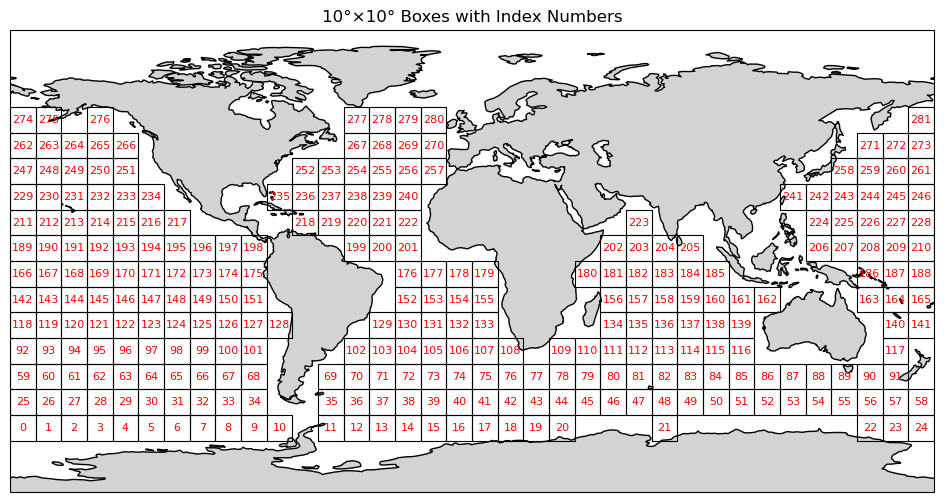

In [55]:


# Load geojson
with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)

for i, feature in enumerate(data["features"]):

    poly = shape(feature["geometry"])

    # Draw box
    ax.add_geometries(
        [poly],
        ccrs.PlateCarree(),
        edgecolor="black",
        facecolor="none",
        linewidth=0.8
    )

    # Get box center
    lon_min, lat_min, lon_max, lat_max = poly.bounds
    lon_c = 0.5 * (lon_min + lon_max)
    lat_c = 0.5 * (lat_min + lat_max)

    # Add number
    ax.text(
        lon_c, lat_c,
        str(i),  # numbering from 1
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=8,
        color="red"
    )

ax.set_title("10°×10° Boxes with Index Numbers")
plt.savefig("Fig/boxes.png",dpi=300,transparent=False)
plt.show()

